In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as mt
import os

In [4]:
def GetThetaMap(Value1,Value2):
    if Value1 == 1.530:
        Temp_Value1 = '1.530'
    elif Value1 == 2.060:
        Temp_Value1 = '2.060'
    else:
        Temp_Value1 = str(Value1)
    Path = 'Ang'+Temp_Value1+'/LAMMPS/'+Value2+'/'
    data = np.genfromtxt(Path+"generateG.xyz", skip_header=4)
    dataI = np.genfromtxt(Path+"generateGInit.xyz", skip_header=4)

    xdata = data[:,1]
    ydata = data[:,2]
    zdata = data[:,3]

    xdataI = dataI[:,1]
    ydataI = dataI[:,2]
    zdataI = dataI[:,3]

    #Make supercell
    g = open(Path+'generateG.xyz','r').readlines()[:4] # Get the unit cell size
    v = g[0].split()
    a1x = float(v[0])
    a1y = float(v[1])
    v = g[1].split()
    a2x = float(v[0])
    a2y = float(v[1])

    xdata_s = []
    ydata_s = []
    zdata_s = []
    xdataI_s = []
    ydataI_s = []
    zdataI_s = []

    for i in [-1,0,1]:
        for j in [-1,0,1]:
            for x,y,z,xI,yI,zI in zip(xdata,ydata,zdata,xdataI,ydataI,zdataI):
                xdata_s.append(x+i*a1x+j*a2x)
                ydata_s.append(y+i*a1y+j*a2y)
                zdata_s.append(z)
                xdataI_s.append(xI+i*a1x+j*a2x)
                ydataI_s.append(yI+i*a1y+j*a2y)
                zdataI_s.append(zI)

    xdata_s = np.array(xdata_s)
    ydata_s = np.array(ydata_s)
    zdata_s = np.array(zdata_s)
    xdataI_s = np.array(xdataI_s)
    ydataI_s = np.array(ydataI_s)
    zdataI_s = np.array(zdataI_s)

    xdataT = xdata_s[zdataI_s>18.0]
    ydataT = ydata_s[zdataI_s>18.0]
    zdataT = zdata_s[zdataI_s>18.0]


    xdataB = xdata_s[zdataI_s<18.0]
    ydataB = ydata_s[zdataI_s<18.0]
    zdataB = zdata_s[zdataI_s<18.0]
    #print(len(xdataB))

    xdataT_A = xdataT[::2]
    ydataT_A = ydataT[::2]
    zdataT_A = zdataT[::2]

    xdataT_B = xdataT[1::2]
    ydataT_B = ydataT[1::2]
    zdataT_B = zdataT[1::2]

    xdataB_A = xdataB[::2]
    ydataB_A = ydataB[::2]
    zdataB_A = zdataB[::2]

    xdataB_B = xdataB[1::2]
    ydataB_B = ydataB[1::2]
    zdataB_B = zdataB[1::2]


    xdataTI = xdataI_s[zdataI_s>18.0]
    ydataTI = ydataI_s[zdataI_s>18.0]
    zdataTI = zdataI_s[zdataI_s>18.0]

    xdataBI = xdataI_s[zdataI_s<18.0]
    ydataBI = ydataI_s[zdataI_s<18.0]
    zdataBI = zdataI_s[zdataI_s<18.0]

    xdataT_AI = xdataTI[::2]
    ydataT_AI = ydataTI[::2]
    zdataT_AI = zdataTI[::2]

    xdataT_BI = xdataTI[1::2]
    ydataT_BI = ydataTI[1::2]
    zdataT_BI = zdataTI[1::2]

    xdataB_AI = xdataBI[::2]
    ydataB_AI = ydataBI[::2]
    zdataB_AI = zdataBI[::2]

    xdataB_BI = xdataBI[1::2]
    ydataB_BI = ydataBI[1::2]
    zdataB_BI = zdataBI[1::2]
    print(len(zdataB_BI)*4, len(zdataBI)*2,len(zdataI_s))

    aG = 2.4602
    aBN = 2.505759

    Final_x = []
    Final_y = []
    Final_z = []
    Final_z_Temp = []
    ind = 0
    fd = open(str(Value1)+"_"+Value2+".dat","w")
    for (xTA,yTA,zTA,xTAI,yTAI,zTAI) in zip(xdataT_A,ydataT_A,zdataT_A,xdataT_AI,ydataT_AI,zdataT_AI):
        ind = ind+1
        if ind == int(len(xdataT_A)):
            print("100%")
        ang_ave = []
        index_ang_x = []
        index_ang_y = []
        for (xTB,yTB,zTB,xTBI,yTBI,zTBI) in zip(xdataT_B,ydataT_B,zdataT_B,xdataT_BI,ydataT_BI,zdataT_BI):
            vecxI = (xTAI-xTBI)
            vecyI = (yTAI-yTBI)
            vecx = (xTA-xTB)
            vecy = (yTA-yTB)
            vecI = [vecxI,vecyI]
            vec = [vecx,vecy]
            len_vec = np.sqrt(vec[0]**2+vec[1]**2)
            len_vecI = np.sqrt(vecI[0]**2+vecI[1]**2)
            if 0.01 < len_vecI and len_vecI < aG/np.sqrt(3)*1.5:
                angle = mt.acos((vec[0]*vecI[0]+vec[1]*vecI[1])/(len_vec*len_vecI))
                s = vecI[0]*vec[1]-vec[0]*vecI[1]
                if s >= 0:
                    ang_ave.append(angle*180/np.pi)
                    index_ang_x.append(vecxI)
                    index_ang_y.append(vecyI)
                elif s < 0:
                    ang_ave.append(-angle*180/np.pi)
                    index_ang_x.append(vecxI)
                    index_ang_y.append(vecyI)
                else:
                    print("Caculate angle error")
        ang_ave_c = sum(ang_ave)/len(ang_ave)
        if xTAI >= -a1x*0.2 and xTAI < a1x*1.7 and yTAI >= -a2y*0.2 and yTAI < a2y*1.2:
            Final_z_Temp.append(ang_ave_c)
        Final_x.append(xTAI)
        Final_y.append(yTAI)
        Final_z.append(ang_ave_c)
        fd.write(str(xTAI)+" "+str(yTAI)+" ")
        for (ele,x,y) in zip(ang_ave,index_ang_x,index_ang_y):
            fd.write(" "+str(ele)+" "+str(x)+" "+str(y)+"      ")
        fd.write("\n")
    #     Final_x.append(elxAI)
    #     Final_y.append(elyAI)
    #     Final_z.append(angleTot/3.0)
    fd.close()
    max_theta = max(Final_z_Temp)
    min_theta = min(Final_z_Temp)

    plt.figure()
    im = plt.scatter(Final_x,Final_y,c=Final_z,cmap="coolwarm",vmax=0.45,vmin=-0.45)
    plt.colorbar(im)
    plt.xlim(0,a1x*1.5)
    plt.ylim(0,a2y)
    plt.gca().set_aspect("equal")
    plt.savefig(str(Value1)+"_"+Value2+"_super.jpg",dpi=400)

    plt.figure()
    im = plt.scatter(Final_x,Final_y,c=Final_z,cmap="coolwarm",vmax=0.45,vmin=-0.45)
    plt.colorbar(im)
    plt.gca().set_aspect("equal")
    plt.savefig(str(Value1)+"_"+Value2+".jpg",dpi=400)
    return max_theta,min_theta

104976 104976 106938
100%
105948 105948 107910
100%
101232 101232 103122
100%
99612 99612 101448
100%
99612 99612 101448
100%
93132 93132 94860
100%
85248 85248 86850
100%
81756 81756 83286
100%
68400 68400 69678
100%
59436 59436 60552
100%
115596 115596 117756
100%


C:\Users\zan\AppData\Local\Temp\ipykernel_25416\2513451925.py:160: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


100908 100908 102798
100%
86868 86868 88488
100%
106308 106308 108288
100%
231444 231444 235764
100%


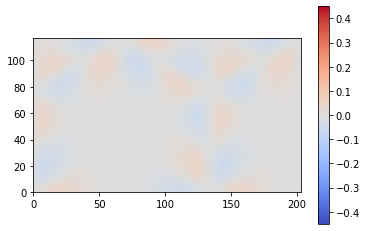

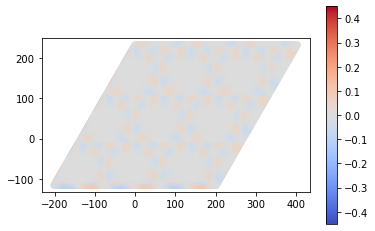

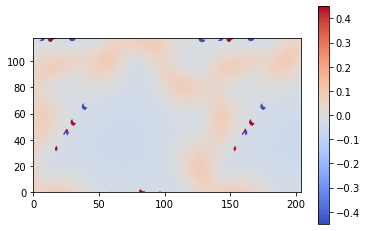

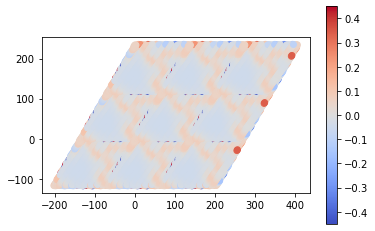

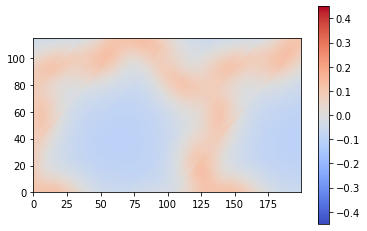

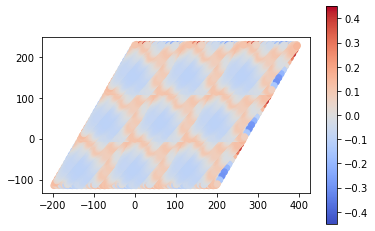

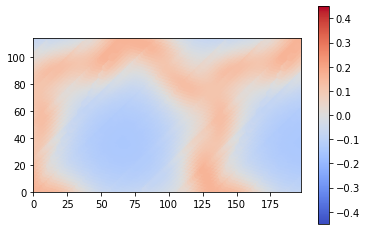

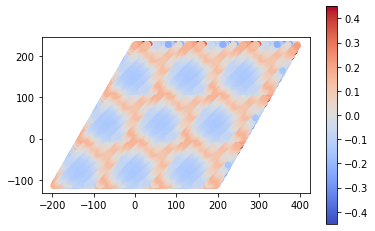

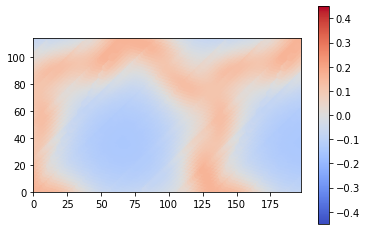

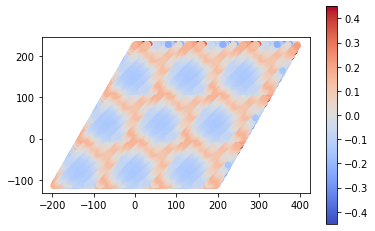

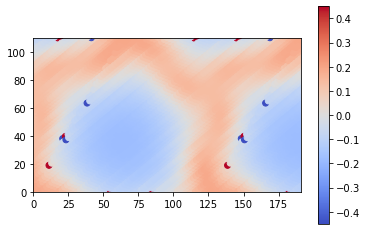

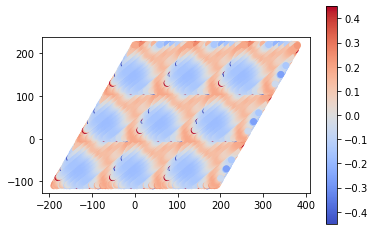

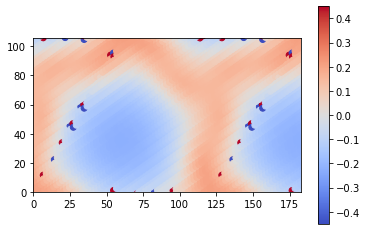

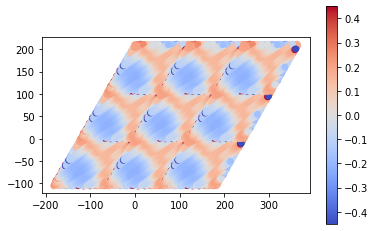

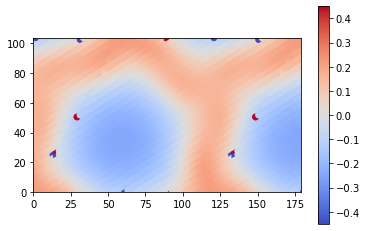

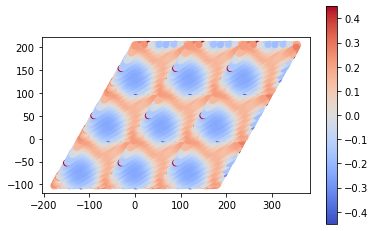

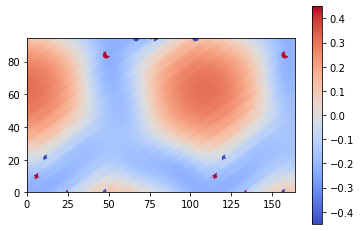

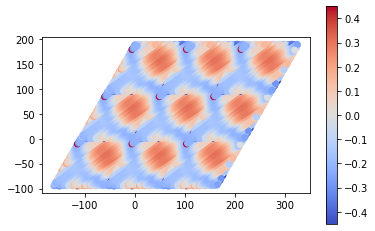

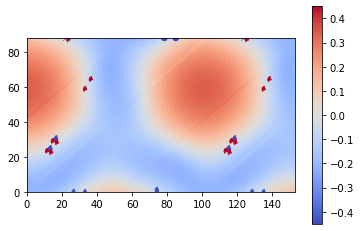

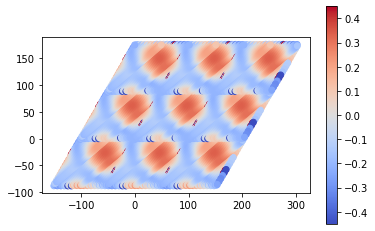

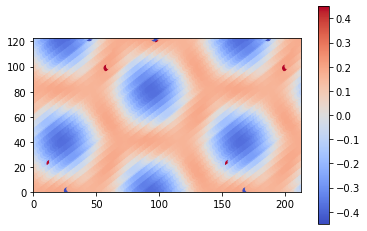

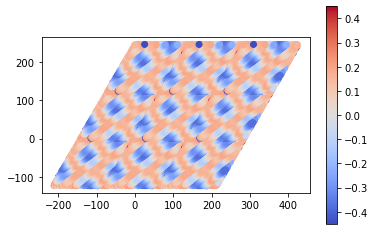

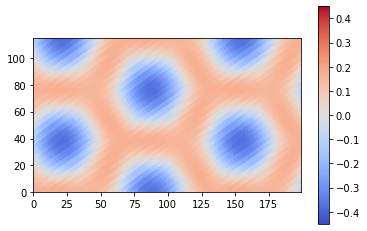

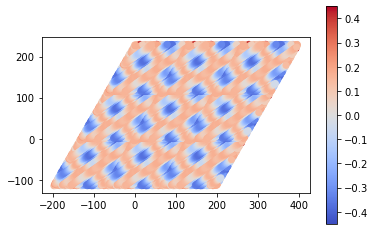

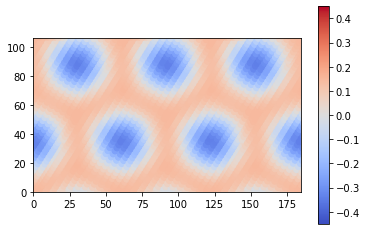

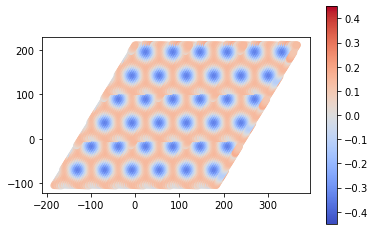

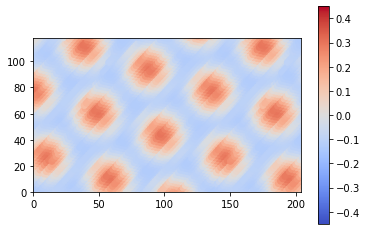

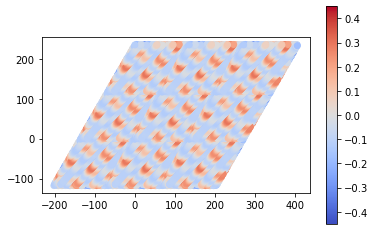

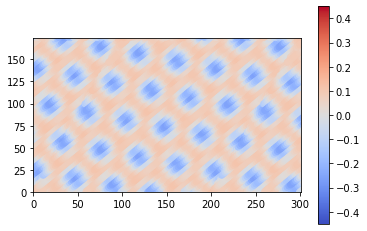

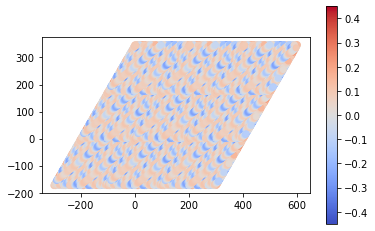

In [5]:
Angle = [0.0]
#Angle = [0.2]
Type = ['FullRelaxed']

MaxTheta = []
MinTheta = []
for i in Angle:
    for tp in Type:
        Value1 = i
        Value2 = tp
        if Value1 == 1.530:
            Temp_Value1 = '1.530'
        elif Value1 == 2.060:
            Temp_Value1 = '2.060'
        else:
            Temp_Value1 = str(Value1)
        Path = 'Ang'+Temp_Value1+'/LAMMPS/'+Value2+'/'
        PreCondition = os.path.isfile(Path+"generateG.xyz")
        if PreCondition == True:
            [max_theta,min_theta] = GetThetaMap(i,tp)
            MaxTheta.append(max_theta)
            MinTheta.append(min_theta)